# Model Explanation Deep Dive
This notebook continues the root cause analysis by focusing on the Random Forest model's explanations, including feature importance and partial dependence plots.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

# Load dataset
df = pd.read_csv('Egencia Analytics Case Study.csv', parse_dates=['BOOKING_DATE', 'TRAVEL_START'], dayfirst=True)

# Clean the dataset
# 1. Convert date columns to datetime format
date_columns = ['BOOKING_DATE', 'TRAVEL_START', 'TRAVEL_END', 'INVOICE_DATE']

for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce')

print("Date conversion completed")
print("Date columns after conversion:")
for col in date_columns:
    print(f"{col}: {df[col].dtype}")

df['PLATFORM'].fillna('Unknown', inplace=True)
#df['ONLINE_PURCHASE_FLAG'] = df['ONLINE_PURCHASE_FLAG'].astype(bool)


df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'])
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'])
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'])
df.head()

Date conversion completed
Date columns after conversion:
BOOKING_DATE: datetime64[ns]
TRAVEL_START: datetime64[ns]
TRAVEL_END: datetime64[ns]
INVOICE_DATE: datetime64[ns]


C:\Users\Dhaval\AppData\Local\Temp\ipykernel_3576\2093960022.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PLATFORM'].fillna('Unknown', inplace=True)


,BOOKING_ID,BOOKING_TYPE_NAME,PRODUCT_NAME,PLATFORM,CUSTOMER_ID,TRAVELER_ID,BOOKING_DATE,TRAVEL_START,TRAVEL_END,INVOICE_DATE,ONLINE_PURCHASE_FLAG,BOOKING_AMOUNT,SAVINGS_AMOUNT,TRANSACTION_COUNT
0,159585350,Reserve,Car,Desktop,0,8833,2018-08-10,2018-09-04,2018-09-07,NaT,True,956.97,0.0,8
1,128623600,Cancel,Car,Desktop,0,8854,2018-08-29,2018-09-04,2018-09-08,NaT,True,-667.20,0.0,4
2,16125082,Reserve,Car,Mobile,0,9166,2018-09-05,2019-03-05,2019-03-12,NaT,True,1327.50,0.0,7
3,129001472,Reserve,Car,Desktop,0,9166,2018-09-05,2019-03-05,2019-03-12,NaT,True,1412.40,0.0,4
4,64792032,Reserve,Car,Desktop,0,1457,2018-09-14,2018-09-21,2018-09-24,NaT,True,375.00,0.0,0


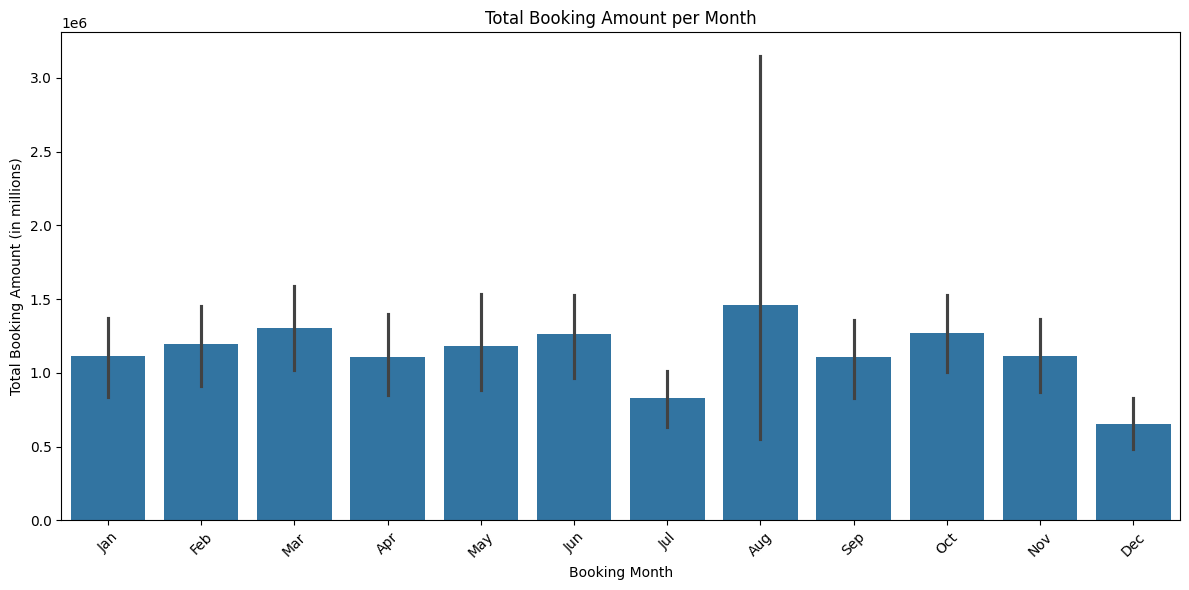

In [8]:
# Plot total booking amount  per month with Y axis as total booking amount in millions and X axis as booking month with only month as label

df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'], format='%m', errors='coerce')
monthly_booking_amount = df.groupby('BOOKING_DATE')['BOOKING_AMOUNT'].sum().reset_index()
monthly_booking_amount['BOOKING_DATE'] = monthly_booking_amount['BOOKING_DATE'].dt.strftime('%b')
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='BOOKING_DATE', y='BOOKING_AMOUNT', data=monthly_booking_amount)
plt.title('Total Booking Amount per Month')
plt.xlabel('Booking Month')     
plt.ylabel('Total Booking Amount (in millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# filter data frame for April and print it in date order
#april_data = df[df['BOOKING_MONTH'] == '2018-04']
#april_data = april_data.sort_values(by='BOOKING_DATE')
#print("April Data in Date Order:")      
#print(april_data[['BOOKING_DATE', 'BOOKING_AMOUNT']])
#april_data.to_csv('april_data.csv', index=False)

In [73]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns

['BOOKING_TYPE_NAME', 'PRODUCT_NAME', 'PLATFORM']

## Preprocessing & Feature Engineering
- Filter only 'Reserve' bookings
- Compute lead time
- Encode categorical features

In [9]:

df['LEAD_TIME_DAYS'] = (df['TRAVEL_START'] - df['BOOKING_DATE']).dt.days
df['TRAVEL_DURATION'] = (df['TRAVEL_START'] - df['TRAVEL_END']).dt.days
# Create a column for month number
df['BOOKING_MONTH'] = df['BOOKING_DATE'].dt.month
df['TRAVEL_START_MONTH'] = df['TRAVEL_START'].dt.month

# Encode categoricals
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"New Data frame with encoding : \n{df_encoded}")

print(df_encoded.columns.tolist())

New Data frame with encoding : 
        BOOKING_ID  CUSTOMER_ID  TRAVELER_ID BOOKING_DATE TRAVEL_START  \
0        159585350            0         8833   2018-08-10   2018-09-04   
1        128623600            0         8854   2018-08-29   2018-09-04   
2         16125082            0         9166   2018-09-05   2019-03-05   
3        129001472            0         9166   2018-09-05   2019-03-05   
4         64792032            0         1457   2018-09-14   2018-09-21   
...            ...          ...          ...          ...          ...   
299994  1673521592         1078         5104   2018-05-06   2018-05-08   
299995   209122116         1078         6856   2018-05-07   2018-05-28   
299996   255842236         1078         4988   2018-09-07   2018-09-10   
299997   200247987         1078         1193   2018-02-06   2018-02-14   
299998   200246503         1078         1189   2018-02-06   2018-02-15   

       TRAVEL_END INVOICE_DATE  ONLINE_PURCHASE_FLAG  BOOKING_AMOUNT  \
0      

['CUSTOMER_ID', 'TRAVELER_ID', 'ONLINE_PURCHASE_FLAG', 'SAVINGS_AMOUNT', 'LEAD_TIME_DAYS', 'TRAVEL_DURATION', 'BOOKING_MONTH', 'TRAVEL_START_MONTH', 'BOOKING_TYPE_NAME_Cancel', 'BOOKING_TYPE_NAME_Exchange', 'BOOKING_TYPE_NAME_Partial Refund', 'BOOKING_TYPE_NAME_Purchase', 'BOOKING_TYPE_NAME_Refund', 'BOOKING_TYPE_NAME_Reserve', 'BOOKING_TYPE_NAME_Void', 'PRODUCT_NAME_Air', 'PRODUCT_NAME_Car', 'PRODUCT_NAME_Hotel', 'PLATFORM_Desktop', 'PLATFORM_Mobile', 'PLATFORM_Unknown']
Model R^2: 0.3892


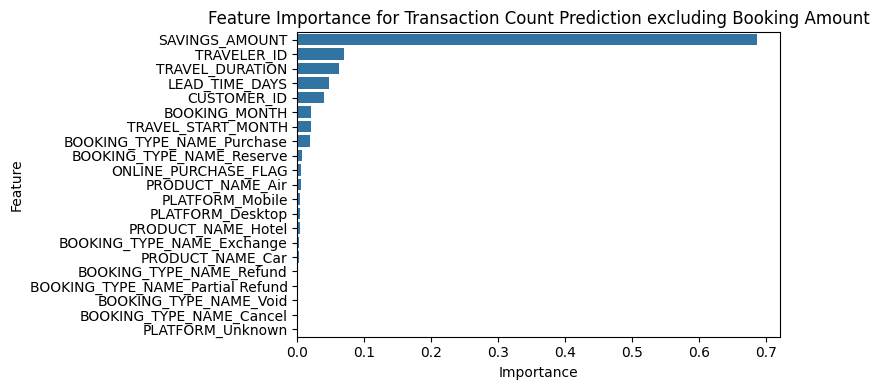

In [11]:
# Filter data frame to exclude Booking amount from training set and remove unsupported dtypes

# Remove datetime and bool columns from features
unsupported_types = ['datetime64[ns]']
X = df_encoded.drop(columns=['TRANSACTION_COUNT','BOOKING_ID','BOOKING_AMOUNT']).copy()
X = X.select_dtypes(exclude=unsupported_types)
print(X.columns.tolist())
y = df_encoded['BOOKING_AMOUNT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
# Train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Evaluate model
print(f"Model R^2: {rf.score(X_test, y_test):.4f}") 
# Feature importance
importances = rf.feature_importances_
feat_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Transaction Count Prediction excluding Booking Amount')
plt.tight_layout()
plt.show()

Model R^2: -0.1959


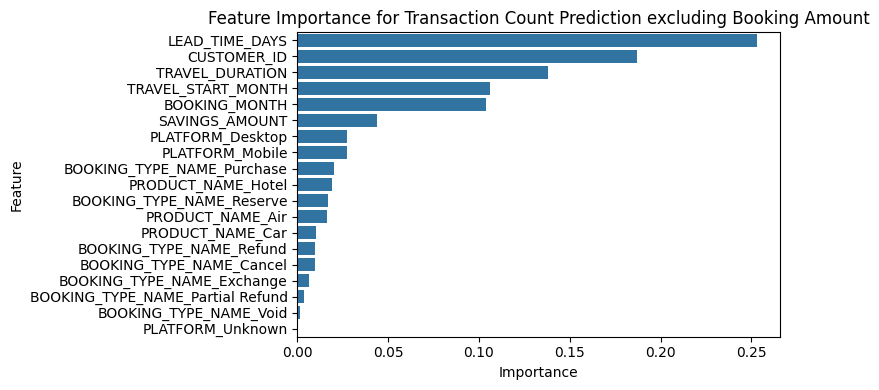

In [12]:
# Filter data frame to exclude Booking amount from training set and remove unsupported dtypes

# Remove datetime and bool columns from features
unsupported_types = ['datetime64[ns]', 'bool']
X = df_encoded.drop(columns=['BOOKING_AMOUNT','BOOKING_ID','TRANSACTION_COUNT','TRAVELER_ID']).copy()
X = X.select_dtypes(exclude=unsupported_types)
y = df_encoded['TRANSACTION_COUNT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
# Train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Evaluate model
print(f"Model R^2: {rf.score(X_test, y_test):.4f}") 
# Feature importance
importances = rf.feature_importances_
feat_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Transaction Count Prediction excluding Booking Amount')
plt.tight_layout()
plt.show()

In [56]:
pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/150.0 MB 4.9 MB/s eta 0:00:31
    --------------------------------------- 2.1/150.0 MB 5.8 MB/s eta 0:00:26
    --------------------------------------- 3.7/150.0 MB 6.6 MB/s eta 0:00:23
   - -------------------------------------- 5.5/150.0 MB 7.3 MB/s eta 0:00:20
   -- ------------------------------------- 7.6/150.0 MB 8.0 MB/s eta 0:00:18
   -- ------------------------------------- 10.0/150.0 MB 8.6 MB/s eta 0:00:17
   --- ------------------------------------ 12.3/150.0 MB 9.0 MB/s eta 0:00:16
   --- ------------------------------------ 14.7/150.0 MB 9.4 MB/s eta 0:00:15
   ---- ----------------------------------- 17.3/150.0 MB 9.6 MB/s eta 0:00:14
   ----- ---------------------------------- 19.7/150.0 MB 9.8 MB/s eta 0:00:14
   ----- ---------------------------------- 22.3/150.0 MB 10.0 MB/s eta 0:00:13
   ------ --------------------------------- 24.6/150.0 MB 10.2 M

XGBoost Model R^2: -0.0087


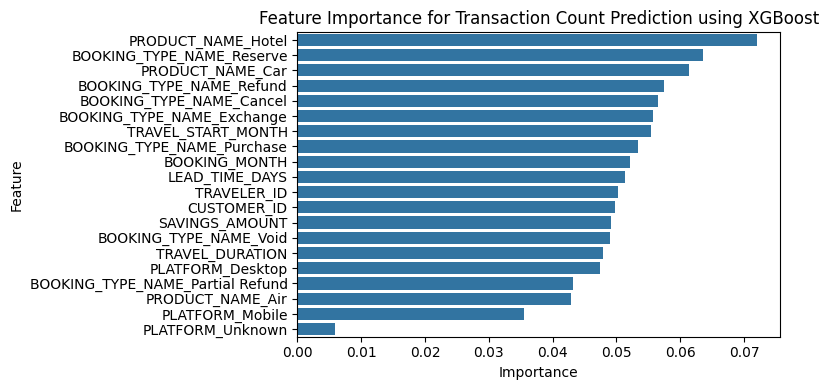

In [13]:
#Implement XGBoost to test feature importance
import xgboost as xgb
unsupported_types = ['datetime64[ns]', 'bool']
X = df_encoded.drop(columns=['BOOKING_AMOUNT','BOOKING_ID','TRANSACTION_COUNT']).copy()
X = X.select_dtypes(exclude=unsupported_types)
y = df_encoded['TRANSACTION_COUNT']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train) 
# Evaluate model
print(f"XGBoost Model R^2: {xgb_model.score(X_test, y_test):.4f}")
# Feature importance
importances = xgb_model.feature_importances_
feat_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Transaction Count Prediction using XGBoost')
plt.tight_layout()
plt.show()

XGBoost Model R^2: 0.3588


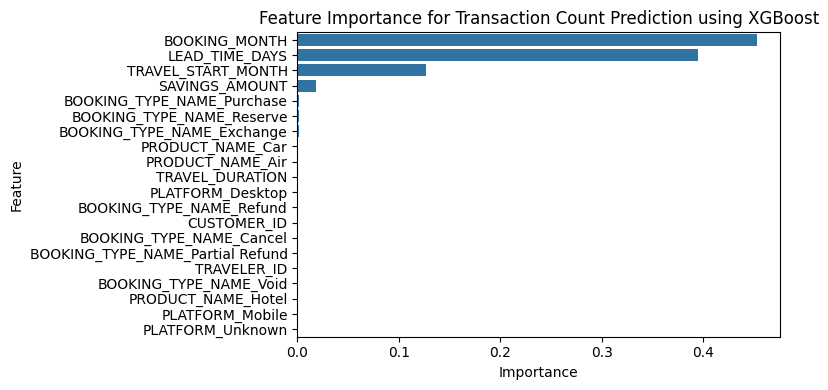

In [14]:
#Implement XGBoost to test feature importance
import xgboost as xgb
unsupported_types = ['datetime64[ns]', 'bool']
X = df_encoded.drop(columns=['BOOKING_AMOUNT','BOOKING_ID','TRANSACTION_COUNT']).copy()
X = X.select_dtypes(exclude=unsupported_types)
y = df_encoded['BOOKING_AMOUNT']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train) 
# Evaluate model
print(f"XGBoost Model R^2: {xgb_model.score(X_test, y_test):.4f}")
# Feature importance
importances = xgb_model.feature_importances_
feat_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Transaction Count Prediction using XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
#label customers a high, medium or low value customer based on booking amount, transaction count, negative booking amount, average booking amount

   BOOKING_ID CLUSTER
0   159585350       0
1   128623600       0
2    16125082       0
3   129001472       0
4    64792032       0


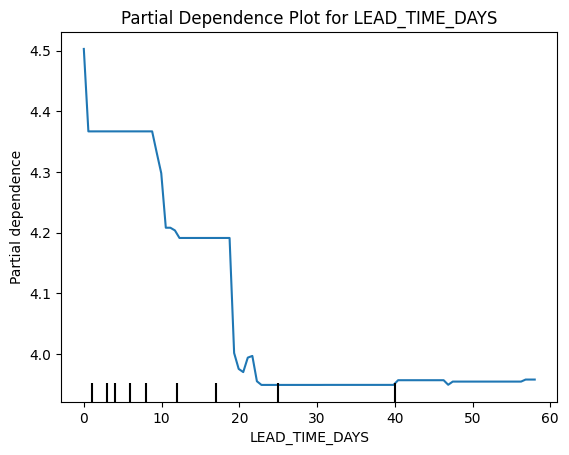

e:\Machine Learning\.venv\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:995: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


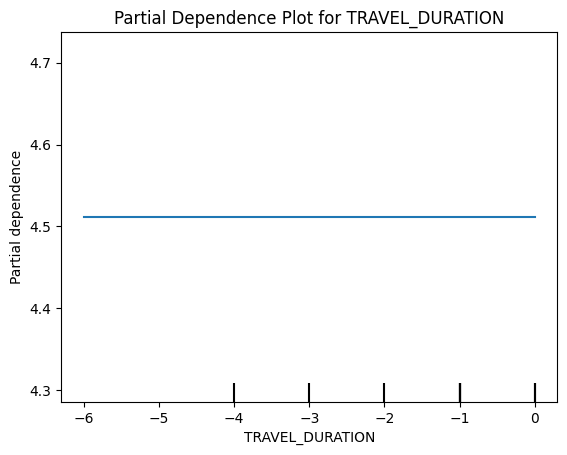

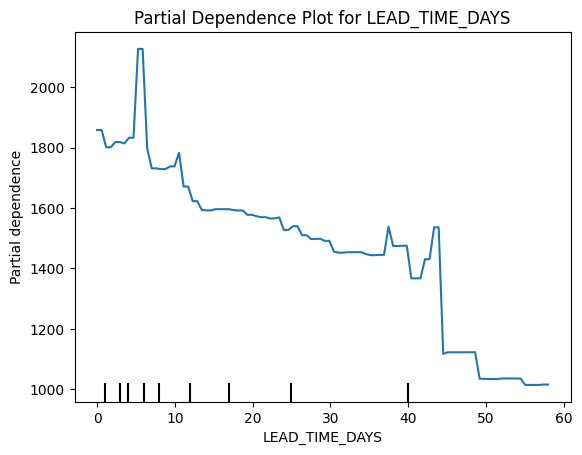

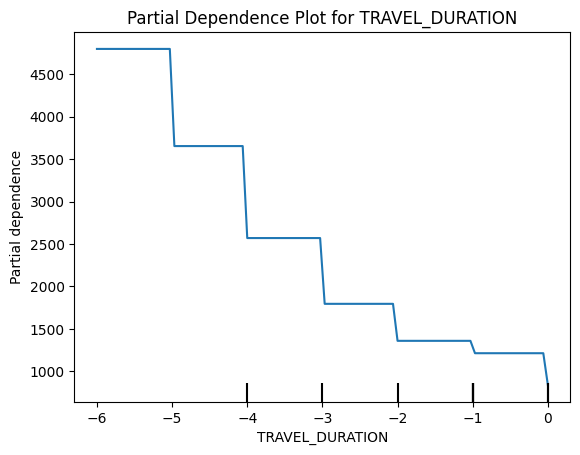

Encoded DataFrame saved to 'Egencia_Analytics_Case_Study_Encoded.csv'


In [17]:
# perform customer segmentation using KMeans clustering to identify distinct customer groups based on booking patterns and behaviors
from sklearn.cluster import KMeans
# Select features for clustering
features_for_clustering = ['LEAD_TIME_DAYS', 'TRAVEL_DURATION', 'BOOKING_AMOUNT', 'TRANSACTION_COUNT']
X_clustering = df_encoded[features_for_clustering].dropna() 
# Perform KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_clustering)
# Add cluster labels to the original dataframe (only for rows used in clustering)
df_encoded['CLUSTER'] = pd.NA
df_encoded.loc[X_clustering.index, 'CLUSTER'] = kmeans.labels_
# Display the first few rows of the dataframe with cluster labels
print(df_encoded[['BOOKING_ID', 'CLUSTER']].head())
# Partial Dependence Plots for Random Forest Model
features = ['LEAD_TIME_DAYS', 'TRAVEL_DURATION']  # Only features present in X_train
for feature in features:
    PartialDependenceDisplay.from_estimator(rf, X_train, [feature])
    plt.title(f'Partial Dependence Plot for {feature}')
    plt.show()
# Partial Dependence Plots for XGBoost Model
for feature in features:
    PartialDependenceDisplay.from_estimator(xgb_model, X_train, [feature])
    plt.title(f'Partial Dependence Plot for {feature}')
    plt.show()
# Save the modified DataFrame to a new CSV file
df_encoded.to_csv('Egencia_Analytics_Case_Study_Encoded.csv', index=False)
print("Encoded DataFrame saved to 'Egencia_Analytics_Case_Study_Encoded.csv'")


C:\Users\Dhaval\AppData\Local\Temp\ipykernel_42748\1604053632.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_bin = df.groupby('LEAD_TIME_BIN')['BOOKING_AMOUNT'].mean().reindex(labels)


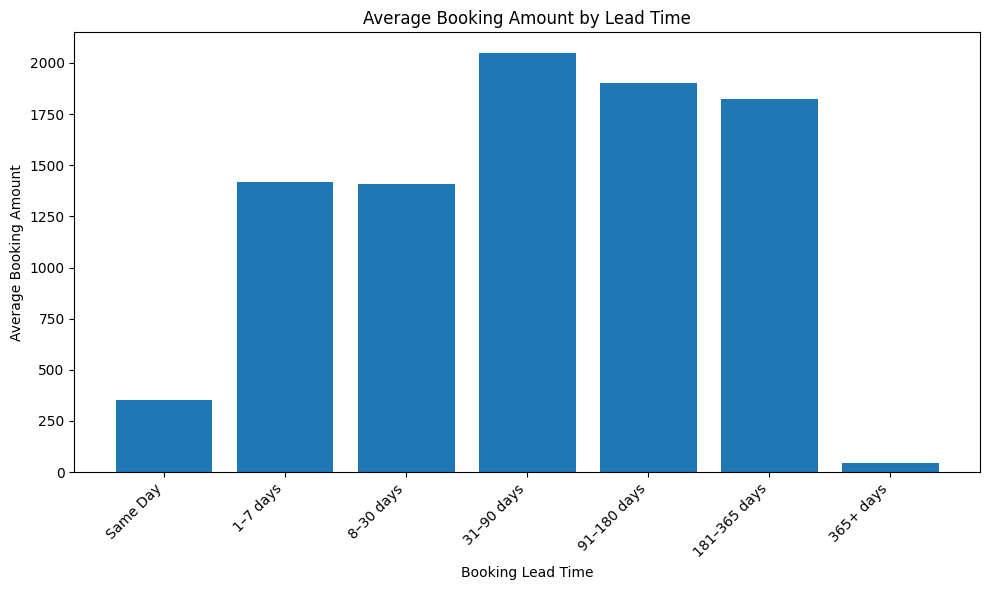

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and preprocess
df = pd.read_csv('Egencia Analytics Case Study.csv',
                 parse_dates=['BOOKING_DATE','TRAVEL_START'],
                 dayfirst=True)
df = df.dropna(subset=['BOOKING_DATE','TRAVEL_START','BOOKING_AMOUNT'])
df['LEAD_TIME_DAYS'] = (df['TRAVEL_START'] - df['BOOKING_DATE']).dt.days.clip(lower=0)

# 2. Bin lead times
bins = [0, 1, 7, 30, 90, 180, 365, df['LEAD_TIME_DAYS'].max()]
labels = [
    'Same Day', '1–7 days', '8–30 days', '31–90 days',
    '91–180 days', '181–365 days', '365+ days'
]
df['LEAD_TIME_BIN'] = pd.cut(df['LEAD_TIME_DAYS'], bins=bins, labels=labels, include_lowest=True)

# 3. Compute average booking value by bin
avg_by_bin = df.groupby('LEAD_TIME_BIN')['BOOKING_AMOUNT'].mean().reindex(labels)

# 4. Plot
plt.figure(figsize=(10,6))
plt.bar(avg_by_bin.index, avg_by_bin.values)
plt.xticks(rotation=45, ha='right')
plt.title('Average Booking Amount by Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('Average Booking Amount')
plt.tight_layout()
plt.show()


C:\Users\Dhaval\AppData\Local\Temp\ipykernel_42748\3942405860.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_bin = df.groupby('LEAD_TIME_BIN')['TRANSACTION_COUNT'].sum().reindex(labels)


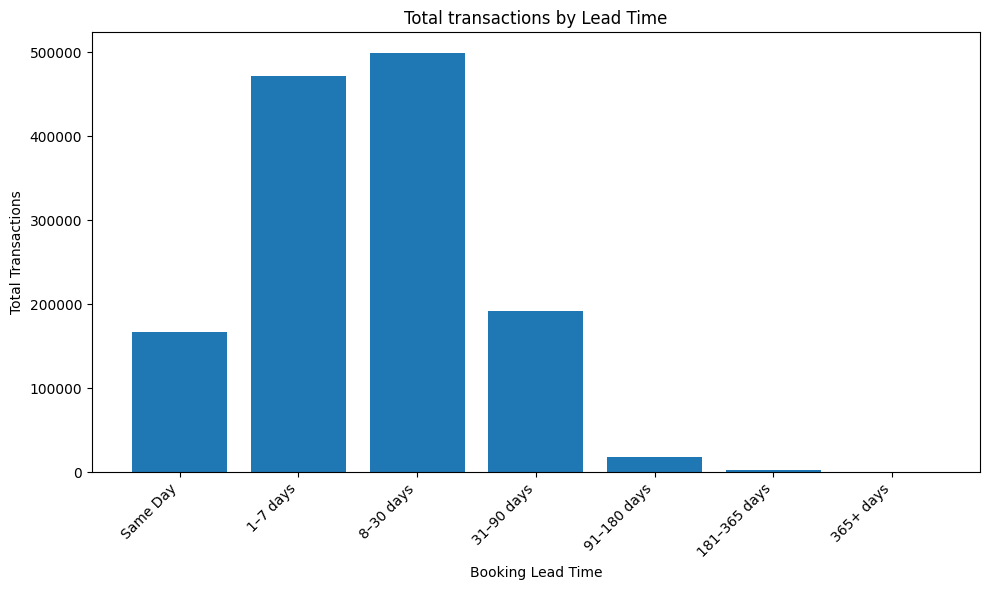

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and preprocess
df = pd.read_csv('Egencia Analytics Case Study.csv',
                 parse_dates=['BOOKING_DATE','TRAVEL_START'],
                 dayfirst=True)
df = df.dropna(subset=['BOOKING_DATE','TRAVEL_START','BOOKING_AMOUNT'])
df['LEAD_TIME_DAYS'] = (df['TRAVEL_START'] - df['BOOKING_DATE']).dt.days.clip(lower=0)

# 2. Bin lead times
bins = [0, 1, 7, 30, 90, 180, 365, df['LEAD_TIME_DAYS'].max()]
labels = [
    'Same Day', '1–7 days', '8–30 days', '31–90 days',
    '91–180 days', '181–365 days', '365+ days'
]
df['LEAD_TIME_BIN'] = pd.cut(df['LEAD_TIME_DAYS'], bins=bins, labels=labels, include_lowest=True)

# 3. Compute average booking value by bin
avg_by_bin = df.groupby('LEAD_TIME_BIN')['TRANSACTION_COUNT'].sum().reindex(labels)

# 4. Plot
plt.figure(figsize=(10,6))
plt.bar(avg_by_bin.index, avg_by_bin.values)
plt.xticks(rotation=45, ha='right')
plt.title('Total transactions by Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('Total Transactions')
plt.tight_layout()
plt.show()


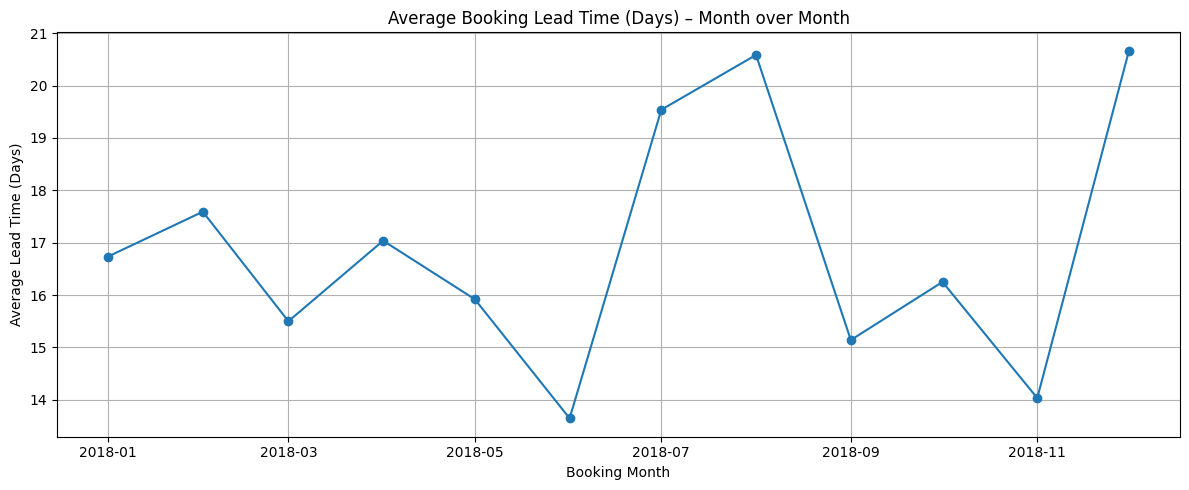

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already loaded with BOOKING_DATE and TRAVEL_START as datetime
# 1. Compute lead time and booking month
df['LEAD_TIME_DAYS'] = (df['TRAVEL_START'] - df['BOOKING_DATE']).dt.days.clip(lower=0)
df['BOOKING_MONTH'] = df['BOOKING_DATE'].dt.to_period('M').dt.to_timestamp()

# 2. Aggregate average lead time per month
monthly_lead = (
    df
    .dropna(subset=['LEAD_TIME_DAYS'])
    .groupby('BOOKING_MONTH')['LEAD_TIME_DAYS']
    .mean()
    .reset_index()
)

# 3. Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly_lead['BOOKING_MONTH'], monthly_lead['LEAD_TIME_DAYS'], marker='o')
plt.title('Average Booking Lead Time (Days) – Month over Month')
plt.xlabel('Booking Month')
plt.ylabel('Average Lead Time (Days)')
plt.grid(True)
plt.tight_layout()
plt.show()


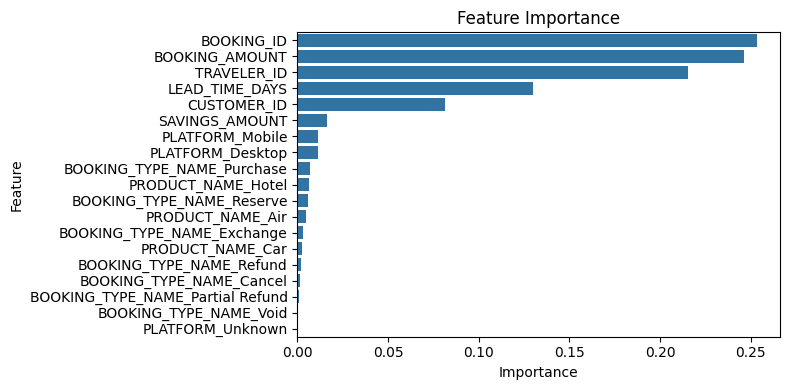

In [ ]:
# Create the month-over-month change chart separately
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Calculate month-over-month percentage changes
monthly_lead_time_analysis['Lead_Time_Change'] = monthly_lead_time_analysis['Lead_Time_Days'].pct_change() * 100
monthly_lead_time_analysis['Transaction_Change'] = monthly_lead_time_analysis['TRANSACTION_COUNT'].pct_change() * 100

# Remove first month (no previous data for percentage change)
change_data = monthly_lead_time_analysis.iloc[1:].copy()

# Create positions for bars
x_pos = np.arange(len(change_data))
width = 0.35

# Create side-by-side bars
bars1 = ax.bar(x_pos - width/2, change_data['Lead_Time_Change'], 
               width, alpha=0.7, color='#C73E1D', label='Lead Time Change (%)')
bars2 = ax.bar(x_pos + width/2, change_data['Transaction_Change'], 
               width, alpha=0.7, color='#2E86AB', label='Transaction Count Change (%)')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Month-over-Month Change (%)', fontsize=12)
ax.set_title('Month-over-Month Changes: Lead Time vs Transaction Count', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(change_data['Month_Label'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Month-over-Month Change Analysis Completed")

## Model Training
Train a Random Forest to predict booking amount.

In [ ]:
# Features and target
X = df[['LEAD_TIME_DAYS','TRANSACTION_COUNT','SAVINGS_AMOUNT','BOOKING_DATE','TRAVEL_START','TRAVEL_END']]
y = df['BOOKING_AMOUNT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

ValueError: could not convert string to float: 'Air'

## Feature Importance
Plot feature importances from the Random Forest model.

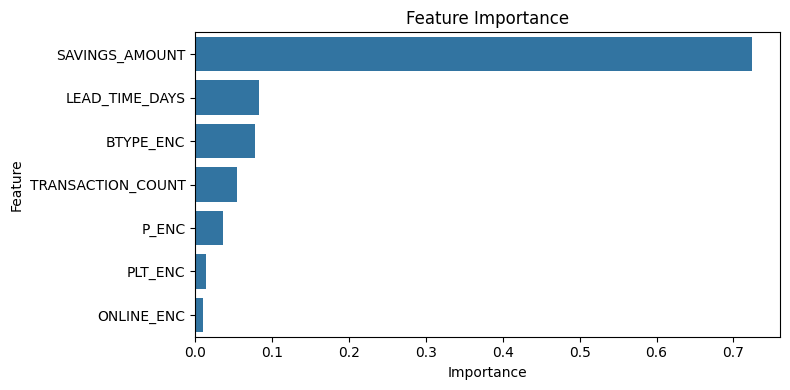

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feat_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Partial Dependence Plots
Visualize the effect of Transaction Count and Lead Time on predicted booking amount.

e:\Machine Learning\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 5 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
e:\Machine Learning\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


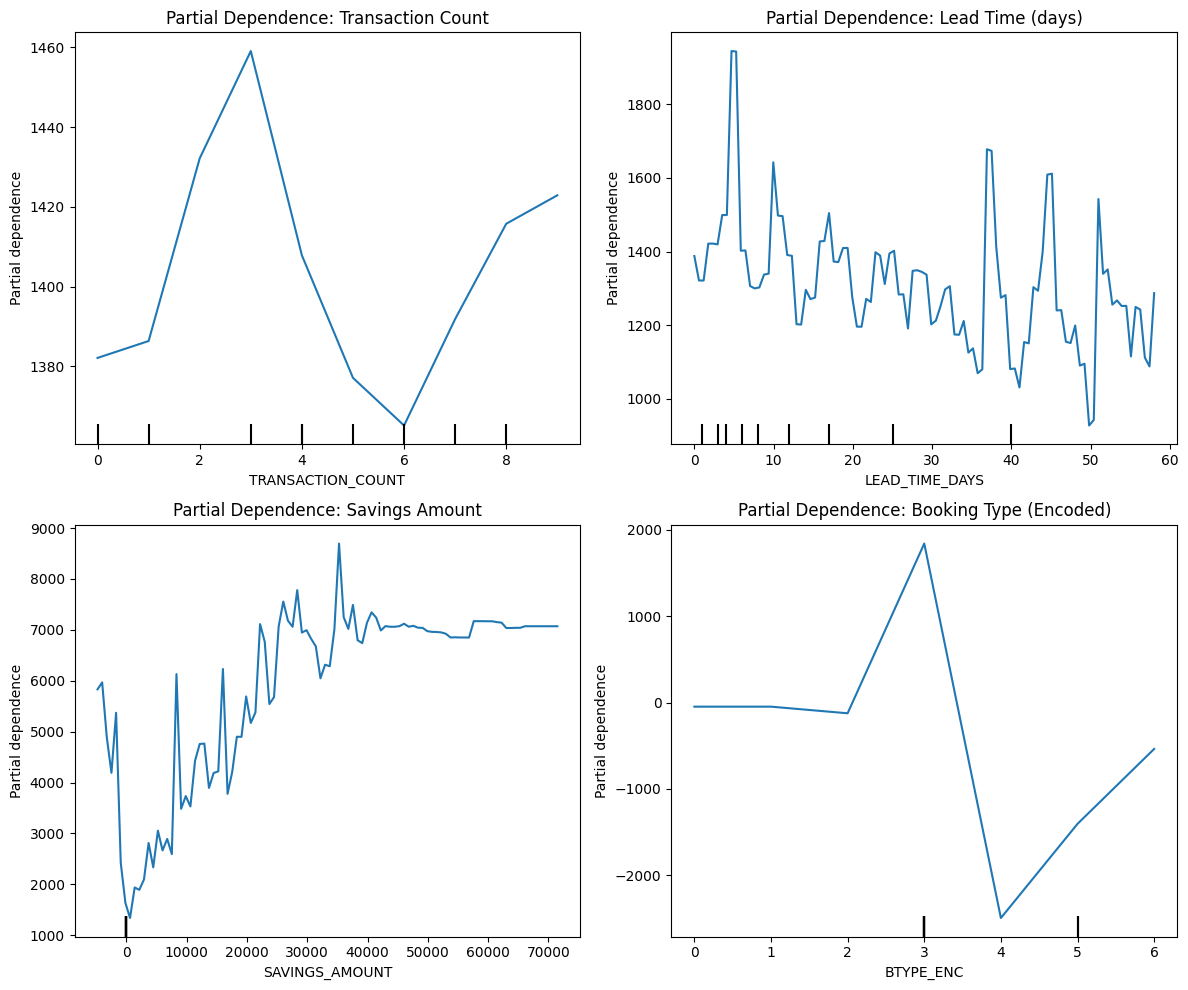

In [12]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(2, 2, figsize=(12,10))
PartialDependenceDisplay.from_estimator(rf, X_train, ['TRANSACTION_COUNT'], ax=ax[0,0])
ax[0,0].set_title('Partial Dependence: Transaction Count')
PartialDependenceDisplay.from_estimator(rf, X_train, ['LEAD_TIME_DAYS'], ax=ax[0,1])
ax[0,1].set_title('Partial Dependence: Lead Time (days)')
PartialDependenceDisplay.from_estimator(rf, X_train, ['SAVINGS_AMOUNT'], ax=ax[1,0], percentiles=(0, 1))
ax[1,0].set_title('Partial Dependence: Savings Amount')
PartialDependenceDisplay.from_estimator(rf, X_train, ['BTYPE_ENC'], ax=ax[1,1])
ax[1,1].set_title('Partial Dependence: Booking Type (Encoded)')
plt.tight_layout()
plt.show()

In [ ]:
# Platform-wise analysis
platform_analysis = df.groupby('PLATFORM').agg({